#Forestfire Dataset II
##Schema of the data
Fires: Table including wildfire data for the period of 1992-2015 compiled from US federal, state, and local reporting systems.

######FOD_ID = Global unique identifier.
######FPA_ID = Unique identifier that contains information necessary to track back to the original record in the source dataset.
######SOURCE_SYSTEM_TYPE = Type of source database or system that the record was drawn from (federal, nonfederal, or interagency).
######SOURCE_SYSTEM = Name of or other identifier for source database or system that the record was drawn from 2014.
######NWCG_REPORTING_AGENCY = Active National Wildlife Coordinating Group (NWCG) Unit Identifier for the agency preparing the fire report (BIA = Bureau of Indian Affairs, BLM = Bureau of Land Management, BOR = Bureau of Reclamation, DOD = Department of Defense, DOE = Department of Energy, FS = Forest Service, FWS = Fish and Wildlife Service, IA = Interagency Organization, NPS = National Park Service, ST/C&L = State, County, or Local Organization, and TRIBE = Tribal Organization).
######NWCG_REPORTING_UNIT_ID = Active NWCG Unit Identifier for the unit preparing the fire report.
######NWCG_REPORTING_UNIT_NAME = Active NWCG Unit Name for the unit preparing the fire report.
######SOURCE_REPORTING_UNIT = Code for the agency unit preparing the fire report, based on code/name in the source dataset.
######SOURCE_REPORTING_UNIT_NAME = Name of reporting agency unit preparing the fire report, based on code/name in the source dataset.
######LOCAL_FIRE_REPORT_ID = Number or code that uniquely identifies an incident report for a particular reporting unit and a particular calendar year.
######LOCAL_INCIDENT_ID = Number or code that uniquely identifies an incident for a particular local fire management organization within a particular calendar year.
######FIRE_CODE = Code used within the interagency wildland fire community to track and compile cost information for emergency fire suppression (https://www.firecode.gov/).
######FIRE_NAME = Name of the incident, from the fire report (primary) or ICS-209 report (secondary).
######ICS_209_INCIDENT_NUMBER = Incident (event) identifier, from the ICS-209 report.
######ICS_209_NAME = Name of the incident, from the ICS-209 report.
######MTBS_ID = Incident identifier, from the MTBS perimeter dataset.
######MTBS_FIRE_NAME = Name of the incident, from the MTBS perimeter dataset.
######COMPLEX_NAME = Name of the complex under which the fire was ultimately managed, when discernible.
######FIRE_YEAR = Calendar year in which the fire was discovered or confirmed to exist.
######DISCOVERY_DATE = Date on which the fire was discovered or confirmed to exist.
######DISCOVERY_DOY = Day of year on which the fire was discovered or confirmed to exist.
######DISCOVERY_TIME = Time of day that the fire was discovered or confirmed to exist.
######STAT_CAUSE_CODE = Code for the (statistical) cause of the fire.
######STAT_CAUSE_DESCR = Description of the (statistical) cause of the fire.
######CONT_DATE = Date on which the fire was declared contained or otherwise controlled (mm/dd/yyyy where mm=month, dd=day, and yyyy=year).
######CONT_DOY = Day of year on which the fire was declared contained or otherwise controlled.
######CONT_TIME = Time of day that the fire was declared contained or otherwise controlled (hhmm where hh=hour, mm=minutes).
######FIRE_SIZE = Estimate of acres within the final perimeter of the fire.
######FIRE_SIZE_CLASS = Code for fire size based on the number of acres within the final fire perimeter expenditures (A=greater than 0 but less than or equal to 0.25 acres, B=0.26-9.9 acres, C=10.0-99.9 acres, D=100-299 acres, E=300 to 999 acres, F=1000 to 4999 acres, and G=5000+ acres).
######LATITUDE = Latitude (NAD83) for point location of the fire (decimal degrees).
######LONGITUDE = Longitude (NAD83) for point location of the fire (decimal degrees).
######OWNER_CODE = Code for primary owner or entity responsible for managing the land at the point of origin of the fire at the time of the incident.
######OWNER_DESCR = Name of primary owner or entity responsible for managing the land at the point of origin of the fire at the time of the incident.
######STATE = Two-letter alphabetic code for the state in which the fire burned (or originated), based on the nominal designation in the fire report.
######COUNTY = County, or equivalent, in which the fire burned (or originated), based on nominal designation in the fire report.
######FIPS_CODE = Three-digit code from the Federal Information Process Standards (FIPS) publication 6-4 for representation of counties and equivalent entities.
######FIPS_NAME = County name from the FIPS publication 6-4 for representation of counties and equivalent entities.

#####Mounting google colab with drive

In [ ]:
from google.colab import drive
# NOTE: this will pop up asking for google login permission1
drive.mount('/content/drive')
# linux command to list the files under linux running
#Colab Jupyter notebook (prints dir/files/links in your Drive)
!ls -ltr /content/drive/MyDrive/ | grep *.csv

Mounted at /content/drive
ls: '/content/drive/MyDrive/dataset (1)': No such file or directory
ls: /content/drive/MyDrive/dataset_csv: No such file or directory
ls: /content/drive/MyDrive/dataset: No such file or directory


#####Checking data in drive

In [ ]:
!ls -ltr /content/drive/MyDrive/surya_data/Fires_V0.csv

-rw------- 1 root root 487860219 Jan 21  2023 /content/drive/MyDrive/surya_data/Fires_V0.csv


#####Importing required moduled and libraries

In [ ]:
import csv
import warnings
import traceback
import numpy as np
%matplotlib inline
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn import svm
from sklearn.svm import SVC
from sklearn import metrics
from tabulate import tabulate
from sklearn import naive_bayes
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.metrics import r2_score
from sklearn.utils import class_weight
warnings.filterwarnings(action='ignore')
from sklearn.metrics import recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics  import f1_score,accuracy_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LinearRegression,LogisticRegression

#####Pretty_print function

In [ ]:
n = 2
def pretty_print(df, n):
  print(tabulate(df.head(n),headers='keys',tablefmt='psql'))

#####Reading csv data file

In [ ]:
df_fire=pd.read_csv('/content/drive/MyDrive/surya_data/Fires_V0.csv').fillna(0)
pretty_print(df_fire, n)
print('Shape', df_fire.shape)

+----+------------+----------+------------+----------------------+-----------------+-------------------------+--------------------------+----------------------------+-------------------------+------------------------------+------------------------+---------------------+-------------+-------------+---------------------------+----------------+-----------+------------------+----------------+-------------+------------------+-----------------+------------------+-------------------+--------------------+-------------+------------+-------------+-------------+-------------------+------------+-------------+--------------+---------------+---------+----------+-------------+-------------+---------+
|    |   OBJECTID |   FOD_ID | FPA_ID     | SOURCE_SYSTEM_TYPE   | SOURCE_SYSTEM   | NWCG_REPORTING_AGENCY   | NWCG_REPORTING_UNIT_ID   | NWCG_REPORTING_UNIT_NAME   |   SOURCE_REPORTING_UNIT | SOURCE_REPORTING_UNIT_NAME   |   LOCAL_FIRE_REPORT_ID | LOCAL_INCIDENT_ID   | FIRE_CODE   | FIRE_NAME   |   ICS_

#####Dropping the columns

In [ ]:
df_fire = df_fire.drop(columns=['NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID','NWCG_REPORTING_UNIT_NAME','SOURCE_REPORTING_UNIT','COMPLEX_NAME','LOCAL_FIRE_REPORT_ID',\
                                'DISCOVERY_TIME', 'CONT_DATE', 'ICS_209_NAME','CONT_DOY','CONT_TIME','MTBS_FIRE_NAME','MTBS_ID','Shape','LOCAL_INCIDENT_ID',\
                                'OWNER_CODE','OWNER_DESCR','ICS_209_INCIDENT_NUMBER','OBJECTID','FOD_ID','FPA_ID'])
pretty_print(df_fire, n)
print('Shape', df_fire.shape)

+----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+----------+-------------+-------------+
|    | SOURCE_SYSTEM_TYPE   | SOURCE_SYSTEM   | SOURCE_REPORTING_UNIT_NAME   | FIRE_CODE   | FIRE_NAME   |   FIRE_YEAR |   DISCOVERY_DATE |   DISCOVERY_DOY |   STAT_CAUSE_CODE | STAT_CAUSE_DESCR   |   FIRE_SIZE | FIRE_SIZE_CLASS   |   LATITUDE |   LONGITUDE | STATE   |   COUNTY |   FIPS_CODE | FIPS_NAME   |
|----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+----------+-------------+-------------|
|  0 | FED                  | FS-FIRESTAT     | Plumas National Forest   

#####Corelation coefficient using seaborn and plotting heatmap

<Figure size 1500x1500 with 0 Axes>

<Axes: >

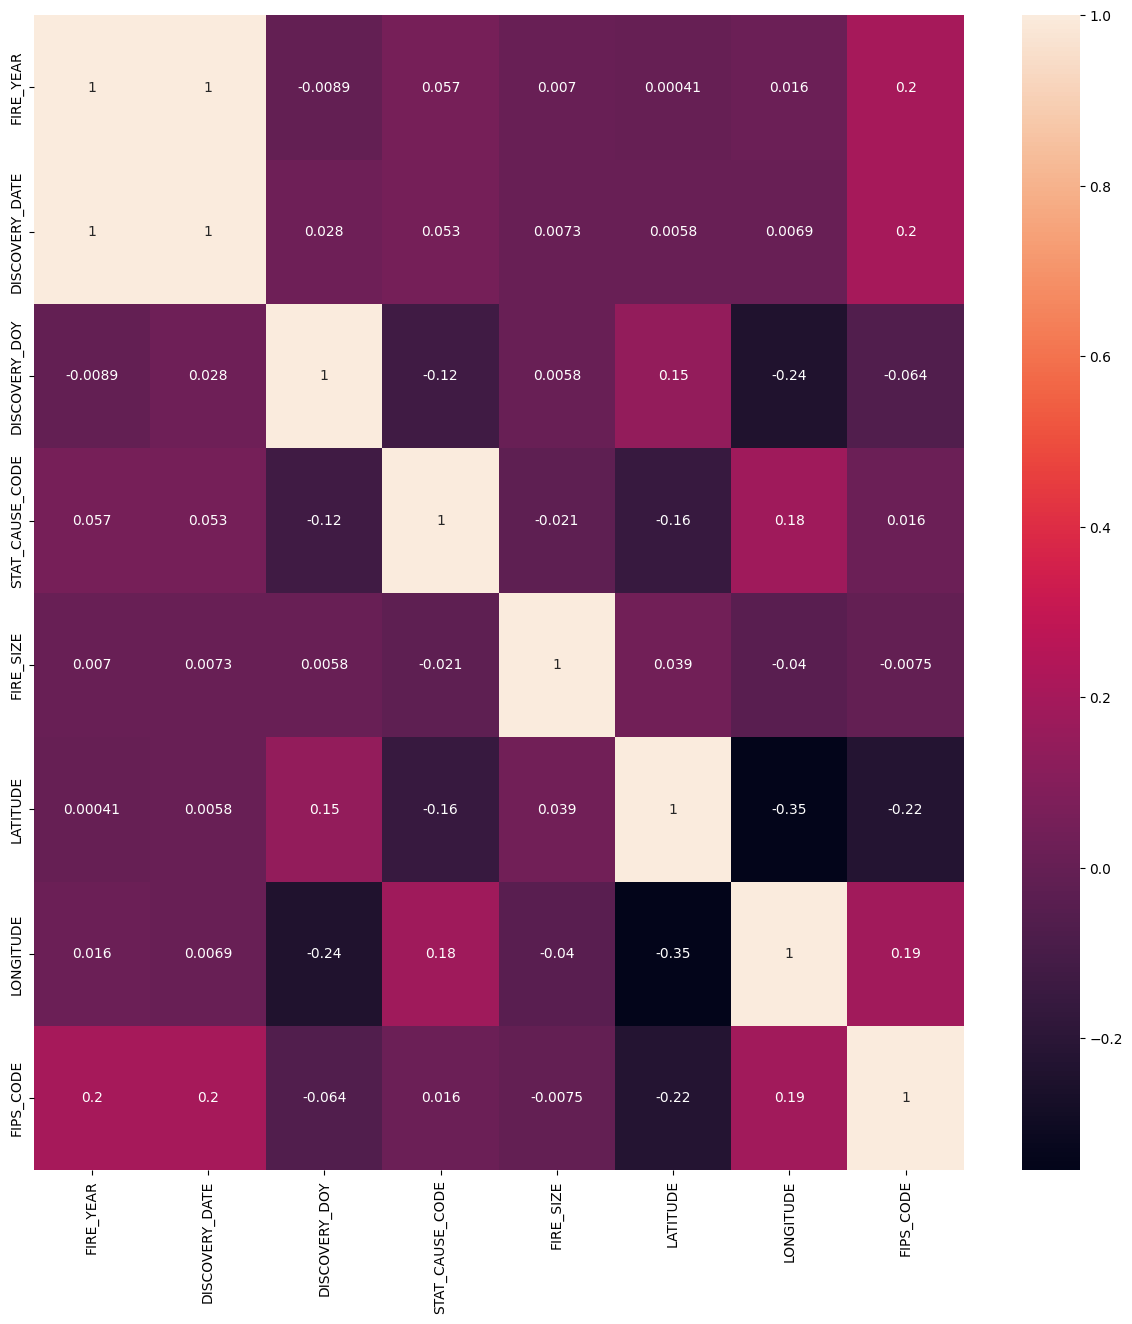

In [ ]:
correlation = df_fire.corr()
plt.figure(figsize = (15,15))
sns.heatmap(correlation, annot=True)

#####Preprocessing and Encoding Data

In [ ]:
#checking for values before ordinal encoding using value_counts
df_fire['SOURCE_REPORTING_UNIT_NAME'].value_counts()
df_fire['DISCOVERY_DATE'].value_counts()
df_fire['DISCOVERY_DOY'].value_counts()
df_fire["SOURCE_SYSTEM"].value_counts()
df_fire["SOURCE_SYSTEM_TYPE"].value_counts()
df_fire["STAT_CAUSE_DESCR"].value_counts()
df_fire["STATE"].value_counts()

Georgia Forestry Commission                97844
Fire Department of New York                75461
South Carolina Forestry Commission         52064
Mississippi Forestry Commission            46396
Texas Forest Service                       42675
                                           ...  
MINGO NWR                                      1
Eagle Mountain VFD                             1
Slade National Wildlife Refuge                 1
Chase Lake National Wildlife Refuge            1
BENTON LAKE WETLAND MANAGEMENT DISTRICT        1
Name: SOURCE_REPORTING_UNIT_NAME, Length: 4441, dtype: int64

2454506.5    1208
2453441.5    1177
2453798.5    1121
2455611.5    1108
2449430.5    1070
             ... 
2450836.5       4
2450828.5       3
2448995.5       2
2448996.5       2
2448998.5       2
Name: DISCOVERY_DATE, Length: 8766, dtype: int64

185    12875
186    11535
101     9261
67      9260
108     9256
       ...  
351     1493
349     1419
348     1347
359     1290
366      544
Name: DISCOVERY_DOY, Length: 366, dtype: int64

ST-NASF        711236
DOI-WFMI       241423
FS-FIRESTAT    220356
ST-CACDF        87355
ST-NCNCS        65695
ST-GAGAS        65061
ST-MSMSS        60513
ST-TXTXS        57945
ST-ALALS        54951
ST-SCSCS        49281
ST-FLFLS        45077
IA-PRIITF       21802
FWS-FMIS        19327
ST-ORORS        18121
ST-LALAS        16172
ST-OKOKS        15397
ST-TNTNS        14777
ST-WIWIS        14323
ST-ARARS        11303
ST-VAVAS        10575
ST-MOMOS         9835
IA-HIWMO         9714
ST-WAWAS         9648
ST-MEMES         7252
ST-KYKYS         6519
ST-UTUTS         4470
ST-NMNMS         4433
IA-AKACC         3713
ST-AZAZS         3446
FA-NFIRS         3387
ST-CTCTS         3379
ST-SDSDS         3181
ST-MTMTS         2737
ST-COCOS         2433
ST-MIMIS         2139
IA-ICS209        1983
ST-WYWYS         1489
ST-NENES           17
Name: SOURCE_SYSTEM, dtype: int64

NONFED       1362148
FED           481106
INTERAGCY      37211
Name: SOURCE_SYSTEM_TYPE, dtype: int64

Debris Burning       429028
Miscellaneous        323805
Arson                281455
Lightning            278468
Missing/Undefined    166723
Equipment Use        147612
Campfire              76139
Children              61167
Smoking               52869
Railroad              33455
Powerline             14448
Fireworks             11500
Structure              3796
Name: STAT_CAUSE_DESCR, dtype: int64

CA    189550
GA    168867
TX    142021
NC    111277
FL     90261
SC     81315
NY     80870
MS     79230
AZ     71586
AL     66570
OR     61088
MN     44769
OK     43239
MT     40767
NM     37478
ID     36698
CO     34157
WA     33513
WI     31861
AR     31663
TN     31154
SD     30963
UT     30725
LA     30013
KY     27089
NJ     25949
PR     22081
WV     21967
VA     21833
MO     17953
NV     16956
ND     15201
WY     14166
ME     13150
AK     12843
MI     10502
HI      9895
PA      8712
NE      7973
KS      7673
CT      4976
IA      4134
MD      3622
OH      3479
MA      2626
NH      2452
IL      2327
IN      2098
RI       480
VT       456
DE       171
DC        66
Name: STATE, dtype: int64

#####Ordinal encoding on multiple columns conversion of categorical to numeric values.

In [ ]:
enc = OrdinalEncoder()
enc.fit(df_fire[["SOURCE_REPORTING_UNIT_NAME","SOURCE_SYSTEM","SOURCE_SYSTEM_TYPE","DISCOVERY_DATE","DISCOVERY_DOY","STAT_CAUSE_DESCR","STATE"]])
df_fire[["SOURCE_REPORTING_UNIT_NAME","SOURCE_SYSTEM","SOURCE_SYSTEM_TYPE",\
         "DISCOVERY_DATE","DISCOVERY_DOY","STAT_CAUSE_DESCR","STATE" ]] = enc.transform(df_fire[["SOURCE_REPORTING_UNIT_NAME","SOURCE_SYSTEM","SOURCE_SYSTEM_TYPE",\
                                                                                                 "DISCOVERY_DATE","DISCOVERY_DOY","STAT_CAUSE_DESCR","STATE"]])
pretty_print(df_fire, n)

OrdinalEncoder()

+----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+----------+-------------+-------------+
|    |   SOURCE_SYSTEM_TYPE |   SOURCE_SYSTEM |   SOURCE_REPORTING_UNIT_NAME | FIRE_CODE   | FIRE_NAME   |   FIRE_YEAR |   DISCOVERY_DATE |   DISCOVERY_DOY |   STAT_CAUSE_CODE |   STAT_CAUSE_DESCR |   FIRE_SIZE | FIRE_SIZE_CLASS   |   LATITUDE |   LONGITUDE |   STATE |   COUNTY |   FIPS_CODE | FIPS_NAME   |
|----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+----------+-------------+-------------|
|  0 |                    0 |               2 |                         3

#####Checking for values after ordinal encoding using values_counts

In [ ]:
df_fire['SOURCE_REPORTING_UNIT_NAME'].value_counts()
df_fire['DISCOVERY_DATE'].value_counts()
df_fire['DISCOVERY_DOY'].value_counts()
df_fire["SOURCE_SYSTEM"].value_counts()
df_fire["SOURCE_SYSTEM_TYPE"].value_counts()
df_fire["STAT_CAUSE_DESCR"].value_counts()
df_fire["STATE"].value_counts()

1560.0    97844
1375.0    75461
3767.0    52064
2627.0    46396
3975.0    42675
          ...  
2424.0        1
1201.0        1
3738.0        1
791.0         1
219.0         1
Name: SOURCE_REPORTING_UNIT_NAME, Length: 4441, dtype: int64

5884.0    1208
4819.0    1177
5176.0    1121
6989.0    1108
808.0     1070
          ... 
2214.0       4
2206.0       3
373.0        2
374.0        2
376.0        2
Name: DISCOVERY_DATE, Length: 8766, dtype: int64

184.0    12875
185.0    11535
100.0     9261
66.0      9260
107.0     9256
         ...  
350.0     1493
348.0     1419
347.0     1347
358.0     1290
365.0      544
Name: DISCOVERY_DOY, Length: 366, dtype: int64

23.0    711236
0.0     241423
2.0     220356
11.0     87355
24.0     65695
15.0     65061
21.0     60513
32.0     57945
8.0      54951
29.0     49281
14.0     45077
7.0      21802
3.0      19327
28.0     18121
17.0     16172
27.0     15397
31.0     14777
36.0     14323
9.0      11303
34.0     10575
20.0      9835
5.0       9714
35.0      9648
18.0      7252
16.0      6519
33.0      4470
26.0      4433
4.0       3713
10.0      3446
1.0       3387
13.0      3379
30.0      3181
22.0      2737
12.0      2433
19.0      2139
6.0       1983
37.0      1489
25.0        17
Name: SOURCE_SYSTEM, dtype: int64

2.0    1362148
0.0     481106
1.0      37211
Name: SOURCE_SYSTEM_TYPE, dtype: int64

3.0     429028
7.0     323805
0.0     281455
6.0     278468
8.0     166723
4.0     147612
1.0      76139
2.0      61167
11.0     52869
10.0     33455
9.0      14448
5.0      11500
12.0      3796
Name: STAT_CAUSE_DESCR, dtype: int64

4.0     189550
10.0    168867
44.0    142021
27.0    111277
9.0      90261
41.0     81315
34.0     80870
25.0     79230
3.0      71586
1.0      66570
37.0     61088
23.0     44769
36.0     43239
26.0     40767
32.0     37478
13.0     36698
5.0      34157
48.0     33513
49.0     31861
2.0      31663
43.0     31154
42.0     30963
45.0     30725
18.0     30013
17.0     27089
31.0     25949
39.0     22081
50.0     21967
46.0     21833
24.0     17953
33.0     16956
28.0     15201
51.0     14166
21.0     13150
0.0      12843
22.0     10502
11.0      9895
38.0      8712
29.0      7973
16.0      7673
6.0       4976
12.0      4134
20.0      3622
35.0      3479
19.0      2626
30.0      2452
14.0      2327
15.0      2098
40.0       480
47.0       456
8.0        171
7.0         66
Name: STATE, dtype: int64

#####Checking for values before label encoding using value_counts

In [ ]:
#checking for values before label encoding using value_counts
df_fire["FIRE_SIZE_CLASS"].value_counts()

B    939376
A    666919
C    220077
D     28427
E     14107
F      7786
G      3773
Name: FIRE_SIZE_CLASS, dtype: int64

#####Label encoding labelling on single column

In [ ]:
# Label encoding labeling on single dataframe
label_encoder = LabelEncoder()
df_fire ['FIRE_SIZE_CLASS'] = label_encoder.fit_transform(df_fire['FIRE_SIZE_CLASS'])
#pretty_print(df_fire, n)

#####Checking for values after label encoding using value_counts

In [ ]:
df_fire["FIRE_SIZE_CLASS"].value_counts()

1    939376
0    666919
2    220077
3     28427
4     14107
5      7786
6      3773
Name: FIRE_SIZE_CLASS, dtype: int64

In [ ]:
df_fire.dtypes

SOURCE_SYSTEM_TYPE            float64
SOURCE_SYSTEM                 float64
SOURCE_REPORTING_UNIT_NAME    float64
FIRE_CODE                      object
FIRE_NAME                      object
FIRE_YEAR                       int64
DISCOVERY_DATE                float64
DISCOVERY_DOY                 float64
STAT_CAUSE_CODE               float64
STAT_CAUSE_DESCR              float64
FIRE_SIZE                     float64
FIRE_SIZE_CLASS                 int64
LATITUDE                      float64
LONGITUDE                     float64
STATE                         float64
COUNTY                         object
FIPS_CODE                     float64
FIPS_NAME                      object
dtype: object

#####Defining function to separate and store str and int values in new columns.

In [ ]:
def convert_list(row, flag):
  col_name = " "
  if flag == 1:
    col_name = 'FIRE_CODE'
  elif flag == 2:
    col_name = 'FIRE_NAME'
  elif flag == 3:
    col_name = 'COUNTY'
  elif flag ==4:
    col_name = 'FIPS_NAME'

  mList = [str(e) if e.isdigit() else str(e) for e in str (row[col_name]).split(',')]
  return mList

lst_cols_names = ["FIRE_CODE", "FIRE_NAME", "COUNTY", "FIPS_NAME"]
for i in range (1,5):
  print(str(i) + ' ' + lst_cols_names[i-1] + '_NEW')
  df_fire[lst_cols_names[i-1] + '_NEW'] = df_fire.apply(convert_list, args=[i], axis=1)
  df_fire = df_fire.explode([lst_cols_names[i-1] + '_NEW'])
pretty_print(df_fire, n)

1 FIRE_CODE_NEW
2 FIRE_NAME_NEW
3 COUNTY_NEW
4 FIPS_NAME_NEW
+----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+----------+-------------+-------------+-----------------+-----------------+--------------+-----------------+
|    |   SOURCE_SYSTEM_TYPE |   SOURCE_SYSTEM |   SOURCE_REPORTING_UNIT_NAME | FIRE_CODE   | FIRE_NAME   |   FIRE_YEAR |   DISCOVERY_DATE |   DISCOVERY_DOY |   STAT_CAUSE_CODE |   STAT_CAUSE_DESCR |   FIRE_SIZE |   FIRE_SIZE_CLASS |   LATITUDE |   LONGITUDE |   STATE |   COUNTY |   FIPS_CODE | FIPS_NAME   | FIRE_CODE_NEW   | FIRE_NAME_NEW   |   COUNTY_NEW | FIPS_NAME_NEW   |
|----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+------

#####Applying ordinal encoding on new columns.

In [ ]:
enc = OrdinalEncoder()
enc.fit(df_fire[["FIRE_CODE_NEW", "FIRE_NAME_NEW", "COUNTY_NEW", "FIPS_NAME_NEW"]])
df_fire[["FIRE_CODE_NEW","FIRE_NAME_NEW", "COUNTY_NEW", "FIPS_NAME_NEW"]] = enc.transform(df_fire[["FIRE_CODE_NEW", "FIRE_NAME_NEW", "COUNTY_NEW", "FIPS_NAME_NEW"]])
pretty_print(df_fire, n)
df_fire.dtypes

OrdinalEncoder()

+----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+----------+-------------+-------------+-----------------+-----------------+--------------+-----------------+
|    |   SOURCE_SYSTEM_TYPE |   SOURCE_SYSTEM |   SOURCE_REPORTING_UNIT_NAME | FIRE_CODE   | FIRE_NAME   |   FIRE_YEAR |   DISCOVERY_DATE |   DISCOVERY_DOY |   STAT_CAUSE_CODE |   STAT_CAUSE_DESCR |   FIRE_SIZE |   FIRE_SIZE_CLASS |   LATITUDE |   LONGITUDE |   STATE |   COUNTY |   FIPS_CODE | FIPS_NAME   |   FIRE_CODE_NEW |   FIRE_NAME_NEW |   COUNTY_NEW |   FIPS_NAME_NEW |
|----+----------------------+-----------------+------------------------------+-------------+-------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------

SOURCE_SYSTEM_TYPE            float64
SOURCE_SYSTEM                 float64
SOURCE_REPORTING_UNIT_NAME    float64
FIRE_CODE                      object
FIRE_NAME                      object
FIRE_YEAR                       int64
DISCOVERY_DATE                float64
DISCOVERY_DOY                 float64
STAT_CAUSE_CODE               float64
STAT_CAUSE_DESCR              float64
FIRE_SIZE                     float64
FIRE_SIZE_CLASS                 int64
LATITUDE                      float64
LONGITUDE                     float64
STATE                         float64
COUNTY                         object
FIPS_CODE                     float64
FIPS_NAME                      object
FIRE_CODE_NEW                 float64
FIRE_NAME_NEW                 float64
COUNTY_NEW                    float64
FIPS_NAME_NEW                 float64
dtype: object

#####Dropping old columns after creating new columns.

In [ ]:
#reusing code for debugging removed LOCAL_FIRE_REPORT_ID, LOCAL_INCIDENT_ID
df_fire_new = df_fire.drop(columns=['FIRE_CODE','FIRE_NAME','COUNTY', 'FIPS_NAME'])
pretty_print(df_fire_new,n)
print("Shape:", df_fire_new.shape)
df_fire_new.dtypes

+----+----------------------+-----------------+------------------------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+-------------+-----------------+-----------------+--------------+-----------------+
|    |   SOURCE_SYSTEM_TYPE |   SOURCE_SYSTEM |   SOURCE_REPORTING_UNIT_NAME |   FIRE_YEAR |   DISCOVERY_DATE |   DISCOVERY_DOY |   STAT_CAUSE_CODE |   STAT_CAUSE_DESCR |   FIRE_SIZE |   FIRE_SIZE_CLASS |   LATITUDE |   LONGITUDE |   STATE |   FIPS_CODE |   FIRE_CODE_NEW |   FIRE_NAME_NEW |   COUNTY_NEW |   FIPS_NAME_NEW |
|----+----------------------+-----------------+------------------------------+-------------+------------------+-----------------+-------------------+--------------------+-------------+-------------------+------------+-------------+---------+-------------+-----------------+-----------------+--------------+-----------------|
|  0 |                   

SOURCE_SYSTEM_TYPE            float64
SOURCE_SYSTEM                 float64
SOURCE_REPORTING_UNIT_NAME    float64
FIRE_YEAR                       int64
DISCOVERY_DATE                float64
DISCOVERY_DOY                 float64
STAT_CAUSE_CODE               float64
STAT_CAUSE_DESCR              float64
FIRE_SIZE                     float64
FIRE_SIZE_CLASS                 int64
LATITUDE                      float64
LONGITUDE                     float64
STATE                         float64
FIPS_CODE                     float64
FIRE_CODE_NEW                 float64
FIRE_NAME_NEW                 float64
COUNTY_NEW                    float64
FIPS_NAME_NEW                 float64
dtype: object

###Data Statistics

In [ ]:
df_fire_new.describe().T

,count,mean,std,min,25%,50%,75%,max
SOURCE_SYSTEM_TYPE,1885057.0,1.469631,0.871604,0.000000,0.000000,2.00000,2.00000,2.000000
SOURCE_SYSTEM,1885057.0,16.096679,10.482732,0.000000,3.000000,23.00000,23.00000,37.000000
SOURCE_REPORTING_UNIT_NAME,1885057.0,2303.887305,1248.781342,0.000000,1375.000000,2457.00000,3369.00000,4440.000000
FIRE_YEAR,1885057.0,2003.721026,6.663862,1992.000000,1998.000000,2004.00000,2009.00000,2015.000000
DISCOVERY_DATE,1885057.0,4445.179295,2434.801911,0.000000,2468.000000,4560.00000,6419.00000,8765.000000
DISCOVERY_DOY,1885057.0,163.704967,90.040921,0.000000,88.000000,163.00000,229.00000,365.000000
STAT_CAUSE_CODE,1885057.0,5.982744,3.485433,1.000000,3.000000,5.00000,9.00000,13.000000
STAT_CAUSE_DESCR,1885057.0,4.519723,2.958766,0.000000,3.000000,4.00000,7.00000,12.000000
FIRE_SIZE,1885057.0,74.453875,2494.859031,0.000010,0.100000,1.00000,3.30000,606945.000000
FIRE_SIZE_CLASS,1885057.0,0.842439,0.831340,0.000000,0.000000,1.00000,1.00000,6.000000


#####Copying existing dataframe to new dataframe.

In [ ]:
df_models = df_fire_new.copy()
df_models.dtypes
print(df_models.shape)

SOURCE_SYSTEM_TYPE            float64
SOURCE_SYSTEM                 float64
SOURCE_REPORTING_UNIT_NAME    float64
FIRE_YEAR                       int64
DISCOVERY_DATE                float64
DISCOVERY_DOY                 float64
STAT_CAUSE_CODE               float64
STAT_CAUSE_DESCR              float64
FIRE_SIZE                     float64
FIRE_SIZE_CLASS                 int64
LATITUDE                      float64
LONGITUDE                     float64
STATE                         float64
FIPS_CODE                     float64
FIRE_CODE_NEW                 float64
FIRE_NAME_NEW                 float64
COUNTY_NEW                    float64
FIPS_NAME_NEW                 float64
dtype: object

(1885057, 18)


#####Creating test & train set

In [ ]:
X = df_models.drop(['FIRE_SIZE_CLASS'], axis=1)  # Keep all features except 'FIRE_SIZE_CLASS'
y = df_models['FIRE_SIZE_CLASS']  # Just keep 'FIRE_SIZE_CLASS'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.65, random_state=1)

#####Feature selection

In [ ]:
selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)
X.columns[selector.get_support(indices=True)].tolist()

# print('Number of input features:', selector.n_features_in_)
# print('Input features Names :', selector.feature_names_in_)
# print('Input features scores :', selector.scores_)
# print('Input features pvalues:', selector.pvalues_)
# print('Output features Names :', selector.get_feature_names_out())

SelectKBest(k='all')

['SOURCE_SYSTEM_TYPE',
 'SOURCE_SYSTEM',
 'SOURCE_REPORTING_UNIT_NAME',
 'FIRE_YEAR',
 'DISCOVERY_DATE',
 'DISCOVERY_DOY',
 'STAT_CAUSE_CODE',
 'STAT_CAUSE_DESCR',
 'FIRE_SIZE',
 'LATITUDE',
 'LONGITUDE',
 'STATE',
 'FIPS_CODE',
 'FIRE_CODE_NEW',
 'FIRE_NAME_NEW',
 'COUNTY_NEW',
 'FIPS_NAME_NEW']

#####Function for choosing either classification or regression.

In [ ]:
def preprocessing(df_models,task):
  df_models = df_models.copy()

  if task=='Regression':
    y = df_models['FIRE_SIZE_CLASS']
  elif task=='Classification':
    y = df_models['FIRE_SIZE_CLASS']

  X = df_models.drop(['FIRE_SIZE_CLASS'],axis=1)

  X_train,X_test,y_train,y_test = train_test_split(X, y, train_size=0.65, shuffle=True, random_state=1)

  scaler=StandardScaler()
  scaler.fit(X_train)

  X_train = pd.DataFrame(scaler.transform(X_train),columns=X.columns)
  X_test = pd.DataFrame(scaler.transform(X_test),columns=X.columns)
  return X_train,X_test,y_train,y_test

#####Choosing task classification.

In [ ]:
X_train, X_test, y_train, y_test = preprocessing(df_models, task='Classification')
X_train.head(1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,SOURCE_REPORTING_UNIT_NAME,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,STAT_CAUSE_CODE,STAT_CAUSE_DESCR,FIRE_SIZE,LATITUDE,LONGITUDE,STATE,FIPS_CODE,FIRE_CODE_NEW,FIRE_NAME_NEW,COUNTY_NEW,FIPS_NAME_NEW
0,0.608257,0.659025,1.337628,1.692031,1.716933,0.692059,-1.143166,-0.175568,-0.028554,-0.550286,0.090267,1.281982,-0.266284,-0.357342,-0.491405,-0.365915,-0.680246


(1225287, 17) (659770, 17) (1225287,) (659770,)


#####Finding mean of label

In [ ]:
m = df_models['FIRE_SIZE'].mean()
print("mean",m)
sd = df_models['FIRE_SIZE'].std()
print("standard deviation",sd)

mean 74.45387485640222
standard deviation 2494.8590310328254


#####Machine learning model (SVM)

In [ ]:
#svm with (C=0.5,cv=2)
svm = SVC(C=0.5, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=0.5, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([207.3908112 , 203.93494797]), 'score_time': array([159.34051633, 155.31519866]), 'test_score': array([0.27004263, 0.2095217 ])}
              precision    recall  f1-score   support

           A     0.4932    0.2883    0.3639    233855
           B     0.6077    0.0158    0.0308    328943
           C     0.0919    0.2185    0.1293     77839
           D     0.0171    0.5389    0.0331     10116
           E     0.7297    0.8436    0.7826      4987
           F     0.9482    0.9656    0.9568      2730
           G     0.9892    0.9869    0.9881      1300

    accuracy                         0.1564    659770
   macro avg     0.5539    0.5511    0.4692    659770
weighted avg     0.5003    0.1564    0.1720    659770

0.5510963068906951


In [ ]:
#svm with (C=3,cv=2)
svm = SVC(C=3, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=3, class_weight='balanced', gamma='auto', kernel='linear', max_iter=1000)

{'fit_time': array([210.87514544, 209.27079487]), 'score_time': array([154.7676847 , 147.59936404]), 'test_score': array([0.24961315, 0.36781943])}
              precision    recall  f1-score   support

           A     0.3933    0.8863    0.5448    233855
           B     0.5835    0.1923    0.2893    328943
           C     0.2434    0.0115    0.0219     77839
           D     0.3752    0.4133    0.3933     10116
           E     0.7735    0.8560    0.8127      4987
           F     0.9516    0.9509    0.9513      2730
           G     0.9801    0.9869    0.9835      1300

    accuracy                         0.4301    659770
   macro avg     0.6144    0.6139    0.5710    659770
weighted avg     0.4765    0.4301    0.3580    659770

0.6138858904365706


In [ ]:
#svm with (C=10,cv=2)
svm = SVC(C=10, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=10, class_weight='balanced', gamma='auto', kernel='linear', max_iter=1000)

{'fit_time': array([201.40696836, 205.11825085]), 'score_time': array([142.97730398, 143.17532539]), 'test_score': array([0.41016316, 0.30070041])}
              precision    recall  f1-score   support

           A     0.4248    0.7966    0.5541    233855
           B     0.5751    0.1922    0.2881    328943
           C     0.1633    0.1811    0.1718     77839
           D     0.5514    0.8667    0.6740     10116
           E     0.9093    0.9102    0.9097      4987
           F     0.9700    0.9703    0.9702      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4257    659770
   macro avg     0.6537    0.7007    0.6504    659770
weighted avg     0.4778    0.4257    0.3835    659770

0.7006964344467244


In [ ]:
#svm with (C=25,cv=2)
svm = SVC(C=25, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=25, class_weight='balanced', gamma='auto', kernel='linear', max_iter=1000)

{'fit_time': array([208.2444284 , 202.31559753]), 'score_time': array([138.55534983, 140.44988918]), 'test_score': array([0.31034173, 0.30361075])}
              precision    recall  f1-score   support

           A     0.4976    0.6547    0.5654    233855
           B     0.6012    0.2372    0.3402    328943
           C     0.1629    0.4259    0.2357     77839
           D     0.7174    0.6727    0.6944     10116
           E     0.7919    0.8464    0.8183      4987
           F     0.9731    0.9670    0.9701      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4232    659770
   macro avg     0.6752    0.6845    0.6584    659770
weighted avg     0.5183    0.4232    0.4206    659770

0.6845192165116346


In [ ]:
#svm with (C=50,cv=2)
svm = SVC(C=50, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=50, class_weight='balanced', gamma='auto', kernel='linear', max_iter=1000)

{'fit_time': array([203.9946146 , 200.45941067]), 'score_time': array([133.63643909, 128.89457631]), 'test_score': array([0.29867427, 0.3392057 ])}
              precision    recall  f1-score   support

           A     0.4301    0.4781    0.4528    233855
           B     0.5775    0.3443    0.4314    328943
           C     0.1457    0.3477    0.2053     77839
           D     0.7394    0.6302    0.6804     10116
           E     0.8864    0.9342    0.9097      4987
           F     0.9547    0.9648    0.9597      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4048    659770
   macro avg     0.6737    0.6696    0.6606    659770
weighted avg     0.4815    0.4048    0.4230    659770

0.6695770956679582


In [ ]:
#svm with (C=75,cv=2)
svm = SVC(C=75, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=75, class_weight='balanced', gamma='auto', kernel='linear', max_iter=1000)

{'fit_time': array([204.61904407, 201.02443933]), 'score_time': array([137.81715155, 126.29753399]), 'test_score': array([0.42497601, 0.37270972])}
              precision    recall  f1-score   support

           A     0.4553    0.4801    0.4673    233855
           B     0.5777    0.5595    0.5684    328943
           C     0.1230    0.1148    0.1187     77839
           D     0.5271    0.6694    0.5898     10116
           E     0.7964    0.8119    0.8041      4987
           F     0.9786    0.9707    0.9746      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4850    659770
   macro avg     0.6344    0.6563    0.6440    659770
weighted avg     0.4840    0.4850    0.4842    659770

0.6562934467553568


In [ ]:
#svm with (C=100,cv=2)
svm = SVC(C=100, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=100, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([211.08341074, 216.90566945]), 'score_time': array([133.545614  , 127.50617552]), 'test_score': array([0.4018141 , 0.33639003])}
              precision    recall  f1-score   support

           A     0.4405    0.4260    0.4332    233855
           B     0.5553    0.4100    0.4717    328943
           C     0.1581    0.3486    0.2176     77839
           D     0.7758    0.7844    0.7801     10116
           E     0.9391    0.9308    0.9349      4987
           F     0.9780    0.9608    0.9693      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4215    659770
   macro avg     0.6899    0.6926    0.6845    659770
weighted avg     0.4766    0.4215    0.4394    659770

0.6926192409003485


In [ ]:
#svm with (C=150,cv=2)
svm = SVC(C=150, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=150, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([219.0255096 , 214.40105414]), 'score_time': array([132.09420776, 124.68818188]), 'test_score': array([0.40107305, 0.3530996 ])}
              precision    recall  f1-score   support

           A     0.3801    0.4196    0.3989    233855
           B     0.5493    0.3974    0.4612    328943
           C     0.1811    0.3253    0.2327     77839
           D     0.5197    0.7407    0.6109     10116
           E     0.8117    0.8785    0.8438      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4092    659770
   macro avg     0.6287    0.6750    0.6441    659770
weighted avg     0.4501    0.4092    0.4205    659770

0.6749950789542244


In [ ]:
#svm with (C=175,cv=2)
svm = SVC(C=175, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=175, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([215.37363529, 214.36220741]), 'score_time': array([129.76850939, 126.49853063]), 'test_score': array([0.48536344, 0.40835691])}
              precision    recall  f1-score   support

           A     0.3539    0.5927    0.4432    233855
           B     0.5605    0.2571    0.3525    328943
           C     0.1911    0.2404    0.2130     77839
           D     0.5978    0.6059    0.6018     10116
           E     0.8457    0.8374    0.8415      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.3883    659770
   macro avg     0.6440    0.6424    0.6305    659770
weighted avg     0.4489    0.3883    0.3795    659770

0.6424371030246704


In [ ]:
#svm with (C=200,cv=2)
svm = SVC(C=200, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=200, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([219.00512743, 218.73349881]), 'score_time': array([130.84353828, 130.38131118]), 'test_score': array([0.46393175, 0.32836252])}
              precision    recall  f1-score   support

           A     0.3203    0.5735    0.4110    233855
           B     0.4720    0.1360    0.2111    328943
           C     0.1418    0.2270    0.1746     77839
           D     0.6462    0.7958    0.7132     10116
           E     0.8719    0.9116    0.8913      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.3229    659770
   macro avg     0.6302    0.6582    0.6232    659770
weighted avg     0.3881    0.3229    0.2952    659770

0.6581851512412624


In [ ]:
#svm with (C=225,cv=2)
svm = SVC(C=225, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=225, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([234.46600842, 250.73880315]), 'score_time': array([137.00209904, 139.09502602]), 'test_score': array([0.44849701, 0.34699327])}
              precision    recall  f1-score   support

           A     0.3596    0.4416    0.3964    233855
           B     0.5421    0.3845    0.4499    328943
           C     0.0997    0.1479    0.1191     77839
           D     0.5168    0.7574    0.6144     10116
           E     0.9536    0.9527    0.9532      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.3905    659770
   macro avg     0.6330    0.6639    0.6420    659770
weighted avg     0.4306    0.3905    0.4015    659770

0.6639435982714653


In [ ]:
#svm with (C=250,cv=2)
svm = SVC(C=250, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=250, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([251.7351675 , 237.62016082]), 'score_time': array([142.38381886, 130.58001947]), 'test_score': array([0.41567697, 0.34958859])}
              precision    recall  f1-score   support

           A     0.4135    0.5090    0.4563    233855
           B     0.5430    0.4492    0.4917    328943
           C     0.1745    0.1776    0.1761     77839
           D     0.6224    0.7091    0.6629     10116
           E     0.9437    0.9453    0.9445      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4493    659770
   macro avg     0.6652    0.6791    0.6704    659770
weighted avg     0.4605    0.4493    0.4509    659770

0.6791004177685792


In [ ]:
#svm with (C=300,cv=2)
svm = SVC(C=300, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=300, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([241.58795071, 239.1989696 ]), 'score_time': array([143.03159356, 129.50382304]), 'test_score': array([0.40962941, 0.42569163])}
              precision    recall  f1-score   support

           A     0.3785    0.4002    0.3890    233855
           B     0.5291    0.5032    0.5158    328943
           C     0.2083    0.2105    0.2094     77839
           D     0.6178    0.7354    0.6715     10116
           E     0.9300    0.9276    0.9288      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4418    659770
   macro avg     0.6604    0.6772    0.6680    659770
weighted avg     0.4450    0.4418    0.4431    659770

0.6771998604280408


In [ ]:
#svm with (C=350,cv=2)
svm = SVC(C=350, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=350, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([239.60099697, 257.92817903]), 'score_time': array([138.6239686 , 132.63754177]), 'test_score': array([0.33189422, 0.42053365])}
              precision    recall  f1-score   support

           A     0.3944    0.5517    0.4600    233855
           B     0.5364    0.4265    0.4752    328943
           C     0.1342    0.0834    0.1029     77839
           D     0.4858    0.6577    0.5588     10116
           E     0.9314    0.9368    0.9341      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.4411    659770
   macro avg     0.6345    0.6599    0.6417    659770
weighted avg     0.4435    0.4411    0.4337    659770

0.659940211606007


In [ ]:
#svm with (C=400,cv=2)
svm = SVC(C=400, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=400, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([244.42580748, 232.33374596]), 'score_time': array([130.95977402, 132.64381766]), 'test_score': array([0.42370773, 0.38179168])}
              precision    recall  f1-score   support

           A     0.4177    0.4354    0.4264    233855
           B     0.5247    0.3711    0.4347    328943
           C     0.1445    0.3011    0.1953     77839
           D     0.6660    0.8022    0.7278     10116
           E     0.8871    0.8843    0.8857      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.3999    659770
   macro avg     0.6570    0.6797    0.6616    659770
weighted avg     0.4496    0.3999    0.4148    659770

0.6796608672529673


In [ ]:
#svm with (C=450,cv=2)
svm = SVC(C=450, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=450, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([228.44178772, 230.47714424]), 'score_time': array([128.92993045, 121.75450635]), 'test_score': array([0.51106679, 0.33920244])}
              precision    recall  f1-score   support

           A     0.3862    0.5929    0.4677    233855
           B     0.4364    0.1529    0.2265    328943
           C     0.2323    0.4946    0.3162     77839
           D     0.7232    0.7768    0.7490     10116
           E     0.8371    0.8235    0.8303      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.3689    659770
   macro avg     0.6535    0.6863    0.6501    659770
weighted avg     0.4053    0.3689    0.3397    659770

0.6863226438378097


In [ ]:
#svm with (C=500,cv=2)
svm = SVC(C=500, kernel='linear', gamma='auto', class_weight='balanced', max_iter=1000)
svm.fit(X_train, y_train)
Y_pred = svm.predict(X_test)
print(cross_validate(svm, X_train, y_train, cv=2))
report = classification_report(y_test, Y_pred, labels=[0,1,2,3,4,5,6], target_names=['A','B','C','D','E','F','G'], digits=4)
print(report)
print(metrics.balanced_accuracy_score(y_test, Y_pred))

SVC(C=500, class_weight='balanced', gamma='auto', kernel='linear',
    max_iter=1000)

{'fit_time': array([234.55539942, 226.12205124]), 'score_time': array([127.14248681, 128.66530824]), 'test_score': array([0.33708483, 0.34406335])}
              precision    recall  f1-score   support

           A     0.3540    0.6183    0.4502    233855
           B     0.4076    0.0999    0.1605    328943
           C     0.1936    0.3744    0.2552     77839
           D     0.6248    0.6910    0.6562     10116
           E     0.8371    0.8235    0.8303      4987
           F     0.9765    0.9758    0.9762      2730
           G     0.9824    0.9877    0.9850      1300

    accuracy                         0.3360    659770
   macro avg     0.6252    0.6530    0.6162    659770
weighted avg     0.3734    0.3360    0.2920    659770

0.6529530436950465
